**Import Libraries**

In [29]:
!pip install torchinfo


In [30]:
import matplotlib.pyplot as plt
import torch
import torchvision
from torch import nn
from torchvision import transforms
from torchinfo import summary
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from typing import Dict, List, Tuple
from PIL import Image
import requests
import torchvision.models as models
from sklearn.metrics import f1_score, roc_auc_score
from torch.nn.functional import one_hot


**Set Device**

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

**Setup Kaggle Download and split Dataset**

In [ ]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d nuha217/arabic-alphabets-sign-language-dataset-arasl
!unzip /content/arabic-alphabets-sign-language-dataset-arasl.zip -d /content/datasetF


Dataset URL: https://www.kaggle.com/datasets/nuha217/arabic-alphabets-sign-language-dataset-arasl
License(s): unknown
arabic-alphabets-sign-language-dataset-arasl.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  /content/arabic-alphabets-sign-language-dataset-arasl.zip
replace /content/datasetF/ArASL_Database_54K_Final/ain/AIN (1).JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Paths
original_data_dir = "/content/datasetF/ArASL_Database_54K_Final"
new_base_dir = "/content/datasetF/ArSLL"
train_dir = os.path.join(new_base_dir, "train")
test_dir = os.path.join(new_base_dir, "test")

# Create train and test directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# For each class, split images into train and test
for class_name in os.listdir(original_data_dir):
    class_dir = os.path.join(original_data_dir, class_name)
    if not os.path.isdir(class_dir):
        continue

    images = os.listdir(class_dir)
    train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)

    # Create class subdirectories
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

    # Move files
    for img in train_imgs:
        shutil.copy(os.path.join(class_dir, img), os.path.join(train_dir, class_name, img))
    for img in test_imgs:
        shutil.copy(os.path.join(class_dir, img), os.path.join(test_dir, class_name, img))

print("Dataset split complete.")


Dataset split complete.


In [32]:
# Setup directory paths to train and test images
train_dir = '/content/datasetF/ArSLL/train'
test_dir = '/content/datasetF/ArSLL/test'

In [33]:
def set_seeds(seed: int=42):
    # Set the seed for general torch operations
    torch.manual_seed(seed)
    # Set the seed for CUDA torch operations (ones that happen on the GPU)
    torch.cuda.manual_seed(seed)

**Load Pretrained Model**

In [34]:
# Load pre-trained MobileNetV2 model with default weights
pretrained_mobilenet_weights = models.MobileNet_V2_Weights.DEFAULT
pretrained_mobilenet = models.mobilenet_v2(weights=pretrained_mobilenet_weights).to("cuda" if torch.cuda.is_available() else "cpu")

# Freeze all layers except the classification head
for param in pretrained_mobilenet.features.parameters():
    param.requires_grad = False

# Get class names
class_names = os.listdir(train_dir)

# Replace the classifier head
pretrained_mobilenet.classifier = nn.Sequential(
    nn.Linear(in_features=1280, out_features=512),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(in_features=512, out_features=len(class_names))
).to("cuda" if torch.cuda.is_available() else "cpu")



In [35]:
# Print summary of the updated model
summary(model=pretrained_mobilenet,
        input_size=(16, 3, 224, 224),  # (batch_size, color_channels, height, width)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [16, 3, 224, 224]    [16, 32]             --                   Partial
├─Sequential (features)                       [16, 3, 224, 224]    [16, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)               [16, 3, 224, 224]    [16, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                        [16, 3, 224, 224]    [16, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                   [16, 32, 112, 112]   [16, 32, 112, 112]   (64)                 False
│    │    └─ReLU6 (2)                         [16, 32, 112, 112]   [16, 32, 112, 112]   --                   --
│    └─InvertedResidual (1)                   [16, 32, 112, 112]   [16, 16, 112, 112]   --                   False
│    │    └─Sequential (conv)                 [16, 32, 112, 112]   [16, 16, 1

**DataLoaders**

In [36]:
NUM_WORKERS = os.cpu_count()
def create_dataloaders(
    train_dir: str,
    test_dir: str,
    transform: transforms.Compose,
    batch_size: int,
    num_workers: int=NUM_WORKERS
):

    # Use ImageFolder to create dataset(s)
    train_data = datasets.ImageFolder(train_dir, transform=transform)
    test_data = datasets.ImageFolder(test_dir, transform=transform)

    # Get class names
    class_names = train_data.classes

    # Turn images into data loaders
    train_dataloader = DataLoader(
        train_data,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )
    test_dataloader = DataLoader(
        test_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    return train_dataloader, test_dataloader, class_names

# Define image transformations compatible with mobilenet
mobilenet_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# Setup dataloaders
train_dataloader, test_dataloader, class_names = create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=mobilenet_transforms,
    batch_size=16
)


**Training Step**

In [37]:
def train_step(model, dataloader, loss_fn, optimizer, device, num_classes):
    model.train()
    train_loss, total_correct, total_samples = 0, 0, 0
    all_preds = []
    all_labels = []

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        # Forward pass
        y_pred = model(X)

        # Loss calculation
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Predictions
        y_pred_class = y_pred.argmax(dim=1)
        total_correct += (y_pred_class == y).sum().item()
        total_samples += y.size(0)

        all_preds.extend(y_pred.softmax(dim=1).detach().cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    train_loss /= len(dataloader)
    train_acc = total_correct / total_samples

    # Compute F1 Score
    y_pred_classes = [p.argmax() for p in all_preds]
    train_f1 = f1_score(all_labels, y_pred_classes, average="weighted")

    # Compute AUC
    try:
        y_true_one_hot = one_hot(torch.tensor(all_labels), num_classes=num_classes).numpy()
        train_auc = roc_auc_score(y_true_one_hot, all_preds, multi_class="ovr", average="weighted")
    except ValueError:
        train_auc = float('nan')

    return train_loss, train_acc, train_f1, train_auc




def test_step(model, dataloader, loss_fn, device, num_classes):
    model.eval()
    test_loss, total_correct, total_samples = 0, 0, 0
    all_preds = []
    all_labels = []

    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            # Forward pass
            test_pred_logits = model(X)

            # Calculate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Predictions
            test_pred_probs = test_pred_logits.softmax(dim=1)
            test_pred_labels = test_pred_probs.argmax(dim=1)

            all_preds.extend(test_pred_probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

            total_correct += (test_pred_labels == y).sum().item()
            total_samples += y.size(0)

    test_loss /= len(dataloader)
    test_acc = total_correct / total_samples

    # Compute F1 Score
    y_pred_classes = [p.argmax() for p in all_preds]
    test_f1 = f1_score(all_labels, y_pred_classes, average="weighted")

    # Compute AUC
    try:
        y_true_one_hot = one_hot(torch.tensor(all_labels), num_classes=num_classes).numpy()
        test_auc = roc_auc_score(y_true_one_hot, all_preds, multi_class="ovr", average="weighted")
    except ValueError:
        test_auc = float('nan')

    return test_loss, test_acc, test_f1, test_auc



def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, epochs, device, num_classes):
    results = {
        "train_loss": [], "train_acc": [], "train_f1": [], "train_auc": [],
        "test_loss": [], "test_acc": [], "test_f1": [], "test_auc": []
    }

    model.to(device)

    for epoch in range(epochs):
        train_loss, train_acc, train_f1, train_auc = train_step(model, train_dataloader, loss_fn, optimizer, device, num_classes)
        test_loss, test_acc, test_f1, test_auc = test_step(model, test_dataloader, loss_fn, device, num_classes)

        print(
            f"Epoch {epoch+1:02} | "
            f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f} | AUC: {train_auc:.4f} || "
            f"Test Loss: {test_loss:.4f} | Acc: {test_acc:.4f} | F1: {test_f1:.4f} | AUC: {test_auc:.4f}"
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["train_f1"].append(train_f1)
        results["train_auc"].append(train_auc)

        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
        results["test_f1"].append(test_f1)
        results["test_auc"].append(test_auc)

    return results


**Train the Model**

In [38]:
# Create optimizer and loss function
optimizer = torch.optim.Adam(params=pretrained_mobilenet.parameters(), lr=1e-4)
loss_fn = torch.nn.CrossEntropyLoss()

# Train the model
device = "cuda" if torch.cuda.is_available() else "cpu"
pretrained_mobilenet_results = train(
    model=pretrained_mobilenet,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=10,
    device=device,
    num_classes= len(train_dataloader.dataset.classes)
)

Epoch 01 | Train Loss: 2.3601 | Acc: 0.3566 | F1: 0.3498 | AUC: 0.8970 || Test Loss: 1.4803 | Acc: 0.6222 | F1: 0.6192 | AUC: 0.9715
Epoch 02 | Train Loss: 1.4651 | Acc: 0.5650 | F1: 0.5611 | AUC: 0.9640 || Test Loss: 1.1254 | Acc: 0.6812 | F1: 0.6776 | AUC: 0.9821
Epoch 03 | Train Loss: 1.2078 | Acc: 0.6314 | F1: 0.6292 | AUC: 0.9749 || Test Loss: 0.9269 | Acc: 0.7346 | F1: 0.7320 | AUC: 0.9868
Epoch 04 | Train Loss: 1.0655 | Acc: 0.6729 | F1: 0.6711 | AUC: 0.9800 || Test Loss: 0.8431 | Acc: 0.7532 | F1: 0.7528 | AUC: 0.9888
Epoch 05 | Train Loss: 0.9624 | Acc: 0.7035 | F1: 0.7024 | AUC: 0.9834 || Test Loss: 0.7641 | Acc: 0.7721 | F1: 0.7695 | AUC: 0.9906
Epoch 06 | Train Loss: 0.8922 | Acc: 0.7225 | F1: 0.7214 | AUC: 0.9856 || Test Loss: 0.6868 | Acc: 0.7970 | F1: 0.7959 | AUC: 0.9921
Epoch 07 | Train Loss: 0.8403 | Acc: 0.7404 | F1: 0.7395 | AUC: 0.9869 || Test Loss: 0.6487 | Acc: 0.8077 | F1: 0.8071 | AUC: 0.9930
Epoch 08 | Train Loss: 0.7895 | Acc: 0.7528 | F1: 0.7521 | AUC: 0.988

**Plot Training and Test Results**

In [39]:
# Plot loss curves of a model
def plot_loss_curves(results):

    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

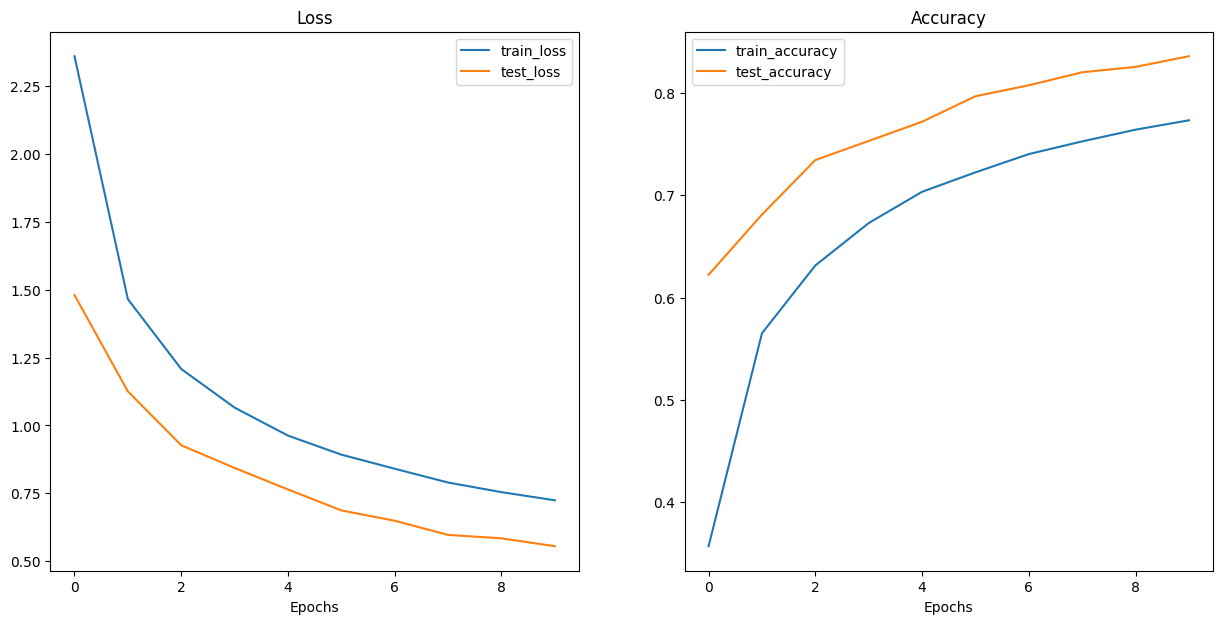

In [40]:
plot_loss_curves(pretrained_mobilenet_results)

# Test the model on real-life data:

1.   preprocess the images



In [45]:
def pred_and_plot_image(
    model: torch.nn.Module,
    class_names: List[str],
    image_path: str,
    image_size: Tuple[int, int] = (224, 224),
    transform: torchvision.transforms = None,
    device: torch.device = device,
):

    # Open image
    img = Image.open(image_path).convert("RGB")

    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose(
            [
                transforms.Resize(image_size),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

    ### Predict on image ###

    # Make sure the model is on the target device
    model.to(device)
    # Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
        # Transform and add an extra dimension to image (model requires samples in [batch_size, color_channels, height, width])
        transformed_image = image_transform(img).unsqueeze(dim=0)
        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(transformed_image.to(device))
    # Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    # Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # Plot image with predicted label and probability
    plt.figure()
    plt.imshow(img)
    plt.title(
        f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}"
    )
    plt.axis(False)


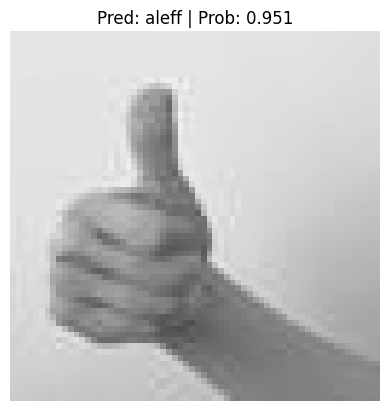

In [46]:
# Setup custom image path
custom_image_path = "/content/datasetF/ArSLL/test/aleff/Aleff (1001).jpg"

# Predict on custom image
pred_and_plot_image(model=pretrained_mobilenet,
                    image_path=custom_image_path,
                    class_names=class_names)

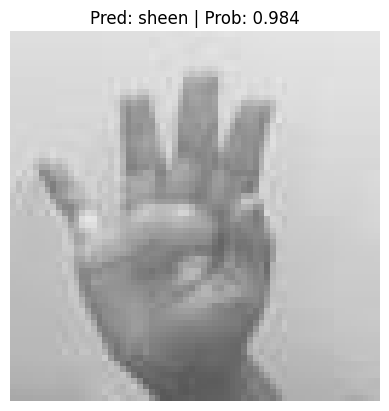

In [47]:
# Setup custom image path
custom_image_path = "/content/datasetF/ArSLL/test/sheen/SHEEN (1013).jpg"

# Predict on custom image
pred_and_plot_image(model=pretrained_mobilenet,
                    image_path=custom_image_path,
                    class_names=class_names)

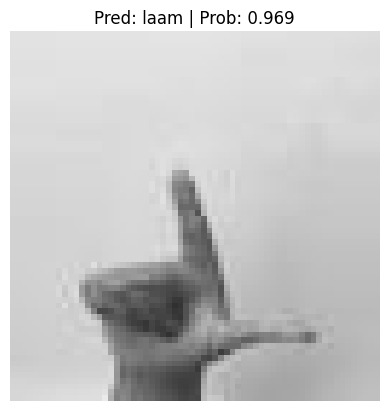

In [49]:
# Setup custom image path
custom_image_path = "/content/datasetF/ArSLL/test/laam/LAAM (1002).jpg"

# Predict on custom image
pred_and_plot_image(model=pretrained_mobilenet,
                    image_path=custom_image_path,
                    class_names=class_names)